In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
# Load all 12 monthly files and merge into one dataset
ds = xr.open_mfdataset('../data/era5/era5_norther_100m_*.nc')
print(f"Loaded {len(ds.valid_time)} hourly records")
print(f"Period: {str(ds.valid_time.values[0])[:10]} to {str(ds.valid_time.values[-1])}")
print(f"Variables: {list(ds.data_vars)}")


Loaded 26304 hourly records
Period: 2023-01-01 to 2025-12-31T23:00:00.000000000
Variables: ['u100', 'v100']


In [2]:
candidate_farms = gpd.read_file("../data/candidate_farms.gpkg")
print(candidate_farms.head())

                name  country      status  power_mw  n_turbines  area_sqkm  \
0            Norther  Belgium  Production     369.6        44.0  38.442050   
1            C-Power  Belgium  Production     325.2        54.0  19.852823   
2             Rentel  Belgium  Production     309.0        42.0  23.265816   
3  Seamade (SeaStar)  Belgium  Production     252.0        30.0  18.425859   
4            Mermaid  Belgium  Production     235.2        28.0  16.267913   

  type_inst                                           geometry  
0  Grounded  MULTIPOLYGON (((502777.3 5706764.815, 498146.6...  
1  Grounded  MULTIPOLYGON (((495673.008 5707997.117, 495000...  
2  Grounded  MULTIPOLYGON (((492188.73 5715538.777, 493455....  
3  Grounded  MULTIPOLYGON (((490574.205 5718251.336, 489176...  
4       NaN  MULTIPOLYGON (((483097 5728870, 480483 5726839...  


In [3]:
print(type(candidate_farms))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [4]:
neighbour_farms = gpd.read_file("../data/neighbor_farms.gpkg")
print(neighbour_farms)

                               name      country      status  power_mw  \
0                  Borssele Kavel V  Netherlands  Production      19.0   
1                   Belwind phase 1      Belgium  Production     165.0   
2                            Rentel      Belgium  Production     309.0   
3                 Seamade (SeaStar)      Belgium  Production     252.0   
4                     Northwester 2      Belgium  Production     219.0   
5                 Borssele Kavel II  Netherlands  Production     376.0   
6                Borssele Kavel III  Netherlands  Production     351.5   
7                 Borssele Kavel IV  Netherlands  Production     380.0   
8                        Borssele I  Netherlands  Production     376.0   
9                           Mermaid      Belgium  Production     235.2   
10                        Northwind      Belgium  Production     216.0   
11  Princess Elisabeth Zone Lot 2.1      Belgium     Planned     700.0   
12  Princess Elisabeth Zone Lot 2.2   

In [5]:
target = candidate_farms.loc[candidate_farms['name'] == "Norther"]

print(target)

      name  country      status  power_mw  n_turbines  area_sqkm type_inst  \
0  Norther  Belgium  Production     369.6        44.0   38.44205  Grounded   

                                            geometry  
0  MULTIPOLYGON (((502777.3 5706764.815, 498146.6...  


In [6]:
# Average across grid points (usually 1-4 points)
u100 = ds['u100'].mean(dim=['latitude', 'longitude']).values
v100 = ds['v100'].mean(dim=['latitude', 'longitude']).values
# Calculate wind speed (Pythagoras)
ws_era5 = np.sqrt(u100**2 + v100**2)
# Calculate wind direction (meteorological convention)
wd_era5 = (270 - np.degrees(np.arctan2(v100, u100))) % 360  # 0 means wind from North
print(f"Mean wind speed: {ws_era5.mean():.1f} m/s")

Mean wind speed: 8.8 m/s


In [7]:
from scipy.stats import weibull_min
import numpy as np

# Direction sectors: 0, 30, 60, ..., 330 degrees
directions = np.arange(0, 360, 30)

results = []

for direction in directions:
    lower = (direction - 15) % 360
    upper = (direction + 15) % 360
   # print(f"Lower: {lower}, Upper: {upper}")

    if lower > upper:
        mask = (wd_era5 >= lower) | (wd_era5 < upper)
       # print(direction, ":", mask)
    else:
        mask = (wd_era5 >= lower) & (wd_era5 < upper)
       # print(direction, ":", mask)

    speeds = ws_era5[mask]
    #print("speeds:", speeds) 
    frequency = len(speeds) / len(ws_era5) * 100
    #print("frequency:", frequency)

    shape, loc, scale = weibull_min.fit(speeds[speeds > 0], floc=0)

    results.append([direction, frequency, scale, shape])

for row in results:
    print(f"{row[0]:3.0f}° | {row[1]:5.1f}% | A={row[2]:5.2f} m/s | k={row[3]:.2f}")

  0° |   5.6% | A= 8.44 m/s | k=2.27
 30° |   8.2% | A= 8.86 m/s | k=2.78
 60° |   7.1% | A= 8.85 m/s | k=2.60
 90° |   5.6% | A= 8.14 m/s | k=2.52
120° |   5.3% | A= 7.21 m/s | k=2.37
150° |   4.8% | A= 7.77 m/s | k=2.14
180° |   9.0% | A=10.53 m/s | k=2.30
210° |  12.9% | A=11.51 m/s | k=2.39
240° |  19.7% | A=11.90 m/s | k=2.71
270° |   9.9% | A=10.31 m/s | k=2.14
300° |   6.6% | A= 9.49 m/s | k=2.04
330° |   5.3% | A= 8.52 m/s | k=2.02


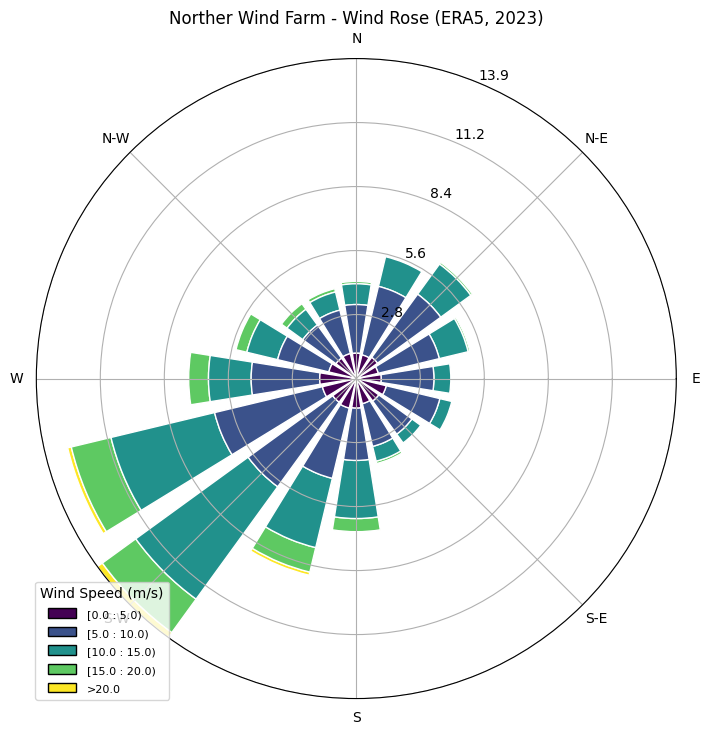

In [8]:
# import matplotlib.pyplot as plt
# from windrose import WindroseAxes
# import os
# from pathlib import Path

# fig = plt.figure(figsize=(8, 8))
# ax = WindroseAxes.from_ax(fig=fig)
# ax.bar(
# wd_era5, ws_era5,
# normed=True,
# opening=0.8,
# edgecolor='white',
# bins=np.arange(0, 25, 5)
# )
# ax.set_title(
# 'Norther Wind Farm - Wind Rose (ERA5, 2023)'
# )
# ax.set_legend(title='Wind Speed (m/s)')

# plt.savefig(
#     "../figures/ wind_rose_norther.png",
#     dpi=150,
#     bbox_inches="tight"
# )
# plt.show()

In [9]:
import numpy as np
import pandas as pd
import xarray as xr
import math
from itertools import product
from shapely.geometry import Polygon, Point

from py_wake.site import XRSite
from py_wake.wind_turbines.generic_wind_turbines import (
    GenericWindTurbine
)
from py_wake.deficit_models import TurboGaussianDeficit
from py_wake.superposition_models import SquaredSum
from py_wake.wind_farm_models import All2AllIterative


/rds/general/user/vk825/home/envs/wake_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# results comes from your Weibull fitting cell
wd_centres = np.array([r[0] for r in results])
sector_freq = np.array([r[1] / 100 for r in results])
weibull_A = np.array([r[2] for r in results])
weibull_k = np.array([r[3] for r in results])

print(f"Sectors: {len(wd_centres)}")
print(f"Freq sum: {sector_freq.sum():.3f}")
print(f"Mean Weibull A: {weibull_A.mean():.2f} m/s")

In [10]:
# Create Site object
def create_site(ti):
    return XRSite(
        ds=xr.Dataset(
            data_vars={
                'Sector_frequency': ('wd', sector_freq),
                'Weibull_A': ('wd', weibull_A),
                'Weibull_k': ('wd', weibull_k),
                'TI': ti,
            },
            coords={'wd': wd_centres}
        )
    )

In [11]:
# Create Generic Wind Turbines
def create_turbine(spec):
    return GenericWindTurbine(
        name=spec['name'],
        diameter=spec['diameter'],
        hub_height=spec['hub_height'],
        power_norm=spec['power'],
        turbulence_intensity=0.06
    )

In [13]:
def place_turbines_in_polygon(
    polygon, n_turbines,
    min_spacing_D=5, rotor_diameter=164
):
    """
    Place n_turbines inside a polygon on a grid
    with minimum spacing of min_spacing_D rotor diameters.
    """
    min_spacing = min_spacing_D * rotor_diameter
    bounds = polygon.bounds
    area = polygon.area
    estimated_spacing = (
        np.sqrt(area / n_turbines) * 0.9
    )
    spacing = max(estimated_spacing, min_spacing)

    x_range = np.arange(
        bounds[0] + spacing / 2, bounds[2], spacing
    )
    y_range = np.arange(
        bounds[1] + spacing / 2, bounds[3], spacing
    )

    points_x, points_y = [], []
    for x in x_range:
        for y in y_range:
            if polygon.contains(Point(x, y)):
                points_x.append(x)
                points_y.append(y)

    points_x = np.array(points_x)
    points_y = np.array(points_y)

    if len(points_x) > n_turbines:
        idx = np.random.choice(
            len(points_x), n_turbines,
            replace=False
        )
        points_x = points_x[idx]
        points_y = points_y[idx]

    return points_x, points_y


In [ ]:
def create_synthetic_neighbour(
    target_centroid, distance_km,
    direction_deg, width_km=4, depth_km=4
):
    """
    Creates a rectangular polygon at a given
    distance and direction from the target farm centroid.
    """
    dist_m = distance_km * 1000
    angle_rad = math.radians(90 - direction_deg)
    center_x = (
        target_centroid.x
        + dist_m * math.cos(angle_rad)
    )
    center_y = (
        target_centroid.y
        + dist_m * math.sin(angle_rad)
    )
    half_w = width_km * 1000 / 2
    half_d = depth_km * 1000 / 2
    return Polygon([
        (center_x - half_w, center_y - half_d),
        (center_x + half_w, center_y - half_d),
        (center_x + half_w, center_y + half_d),
        (center_x - half_w, center_y + half_d)
    ])


In [14]:
def simulate_wake_loss(
    target_poly, target_turbines,
    nb_poly, nb_turbines,
    t_spec, spacing_D, ti
):
    """
    Runs one PyWake simulation.
    Returns: (aep_alone_gwh, aep_with_nb_gwh, wake_loss_pct)
    """
    site = create_site(ti)
    wt = create_turbine(t_spec)

    turbopark = All2AllIterative(
        site, wt,
        wake_deficitModel=TurboGaussianDeficit(),
        superpositionModel=SquaredSum()
    )

    # Place turbines in target farm
    x_target, y_target = place_turbines_in_polygon(
        target_poly,
        n_turbines=target_turbines,
        min_spacing_D=spacing_D,
        rotor_diameter=t_spec['diameter']
    )
    n_target = len(x_target)

    # Baseline: target alone
    sim_alone = turbopark(
        x_target, y_target,
        wd=wd_centres,
        ws=np.arange(3, 26, 1)
    )
    aep_alone = float(
        sim_alone.aep().sum().values
    )

    # With neighbour
    if nb_turbines > 0 and nb_poly is not None:
        x_nb, y_nb = place_turbines_in_polygon(
            nb_poly,
            n_turbines=nb_turbines,
            min_spacing_D=5,
            rotor_diameter=t_spec['diameter']
        )
        # Concatenate all turbines
        all_x = np.concatenate([x_target, x_nb])
        all_y = np.concatenate([y_target, y_nb])

        sim_with = turbopark(
            all_x, all_y,
            wd=wd_centres,
            ws=np.arange(3, 26, 1)
        )
        # Extract AEP for TARGET turbines only
        aep_with = float(
            sim_with.aep()
            .isel(wt=slice(0, n_target))
            .sum().values
        )
        loss_pct = (1 - aep_with / aep_alone) * 100
    else:
        aep_with = aep_alone
        loss_pct = 0.0

    return aep_alone, aep_with, loss_pct


In [15]:
def generate_training_data(
    scenarios, csv_path='training_data.csv'
):
    """
    Runs all scenarios and saves to CSV.
    Saves progress every 50 simulations.
    """
    results_list = []
    total = len(scenarios)
    print(f"Starting {total} scenarios...")

    for i, s in enumerate(scenarios):
        t_spec = s['turbine_spec']

        try:
            aep_alone, aep_with, loss_pct = (
                simulate_wake_loss(
                    target_poly=s['target_poly'],
                    target_turbines=s['target_turbines'],
                    nb_poly=s['nb_poly'],
                    nb_turbines=s['nb_turbines'],
                    t_spec=t_spec,
                    spacing_D=s['spacing_D'],
                    ti=s['ti']
                )
            )
        except Exception as e:
            print(f"  Scenario {i} failed: {e}")
            aep_alone, aep_with, loss_pct = (
                np.nan, np.nan, np.nan
            )

        results_list.append({
            'ti': s['ti'],
            'turbine_name': t_spec['name'],
            'rotor_diam_m': t_spec['diameter'],
            'hub_height_m': t_spec['hub_height'],
            'rated_power_kw': t_spec['power'],
            'target_spacing_D': s['spacing_D'],
            'nb_distance_km': s.get(
                'nb_distance_km', np.nan
            ),
            'nb_direction_deg': s.get(
                'nb_direction_deg', np.nan
            ),
            'nb_n_turbines': s['nb_turbines'],
            'aep_alone_gwh': aep_alone,
            'aep_with_nb_gwh': aep_with,
            'wake_loss_pct': loss_pct
        })

        # Save progress every 50 sims
        if (i + 1) % 50 == 0:
            df = pd.DataFrame(results_list)
            df.to_csv(csv_path, index=False)
            print(
                f"  Progress: {i+1}/{total} "
                f"saved to {csv_path}"
            )

    # Final save
    df = pd.DataFrame(results_list)
    df.to_csv(csv_path, index=False)
    print(f"\nDone! {len(df)} rows -> {csv_path}")
    return df


In [16]:
norther_poly = target.geometry.iloc[0]

In [ ]:
# --- Define all parameter variations ---

# Turbine specs
turbine_specs = [
    {'name': '8MW', 'diameter': 164,
     'hub_height': 105, 'power': 8000},
    {'name': '10MW', 'diameter': 178,
     'hub_height': 119, 'power': 10000},
    {'name': '15MW', 'diameter': 240,
     'hub_height': 150, 'power': 15000},
]

# Target farm spacing
spacings = [4, 5, 6]  # rotor diameters

# Turbulence intensity
ti_values = [0.04, 0.06, 0.08, 0.10]

# Neighbour distance
nb_distances = [5, 10, 15, 20, 25]  # km

# Neighbour direction
nb_directions = np.arange(0, 360, 30)  # 12 dirs

# Neighbour size
nb_sizes = [30, 60, 90]  # turbines

# --- Build scenario list ---
target_centroid = norther_poly.centroid
all_scenarios = []

for t_spec, spacing, ti, dist, dir_deg, nb_turb in product(
    turbine_specs, spacings, ti_values,
    nb_distances, nb_directions, nb_sizes
):
    nb_poly = create_synthetic_neighbour(
        target_centroid, dist, dir_deg
    )
    all_scenarios.append({
        'target_poly': norther_poly,
        'target_turbines': 44,
        'nb_poly': nb_poly,
        'nb_turbines': nb_turb,
        'nb_distance_km': dist,
        'nb_direction_deg': dir_deg,
        'turbine_spec': t_spec,
        'spacing_D': spacing,
        'ti': ti,
    })

print(f"Total scenarios: {len(all_scenarios)}")
print("5 turbines x 3 spacings x 4 TI "
      "x 5 distances x 12 directions x 3 sizes")


In [ ]:
df = generate_training_data(
    all_scenarios, '../data/full_training_data.csv'
)


In [ ]:
# Load and inspect
df = pd.read_csv('full_training_data.csv')
print(f"Total rows: {len(df)}")
print(f"\nWake loss statistics:")
print(df['wake_loss_pct'].describe())

print(f"\nWake loss by turbine type:")
print(
    df.groupby('turbine_name')['wake_loss_pct']
    .mean()
)

print(f"\nWake loss by distance:")
print(
    df.groupby('nb_distance_km')['wake_loss_pct']
    .mean()
)


In [ ]:
# Real farms scenarios
real_scenarios = []

# Use neighbour_farms from load_emodnet notebook
for idx, row in neighbour_farms.iterrows():
    n_turb = int(row['n_turbines']) if (
        pd.notna(row.get('n_turbines'))
    ) else 0

    # Estimate turbines from power if missing
    if n_turb == 0 and pd.notna(row.get('power_mw')):
        n_turb = int(row['power_mw'] / 8)

    if n_turb <= 0:
        continue

    # Calculate distance and direction
    nb_centroid = row['geometry'].centroid
    dx = nb_centroid.x - target_centroid.x
    dy = nb_centroid.y - target_centroid.y
    dist_km = np.sqrt(dx**2 + dy**2) / 1000
    dir_deg = (90 - np.degrees(
        np.arctan2(dy, dx)
    )) % 360

    # Try with different TI and turbine specs
    for ti in [0.04, 0.06, 0.08, 0.10]:
        for t_spec in turbine_specs:
            real_scenarios.append({
                'target_poly': norther_poly,
                'target_turbines': 44,
                'nb_poly': row['geometry'],
                'nb_turbines': n_turb,
                'nb_distance_km': dist_km,
                'nb_direction_deg': dir_deg,
                'turbine_spec': t_spec,
                'spacing_D': 5,
                'ti': ti,
            })

print(f"Real farm scenarios: {len(real_scenarios)}")

# Run and save separately
df_real = generate_training_data(
    real_scenarios, '../data/real_farms_training_data.csv'
)


In [ ]:
# Combine synthetic + real into one CSV
df_synth = pd.read_csv('../data/full_training_data.csv')
df_real = pd.read_csv('../data/real_farms_training_data.csv')

df_all = pd.concat(
    [df_synth, df_real], ignore_index=True
)
df_all.to_csv(
    '../data/training_data.csv', index=False
)
print(f"Combined: {len(df_all)} total rows")
print(f"  Synthetic: {len(df_synth)}")
print(f"  Real farms: {len(df_real)}")
